# End_to_End_Toy_ML_Project

In [4]:
import numpy as np
import pandas as pd
df = pd.read_csv('placement-dataset.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape

(100, 4)

In [6]:
# Steps
# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the value
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy thee model

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [8]:
# preprocessing - removed unnamed coulumn
df = df.iloc[:,1:]

In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


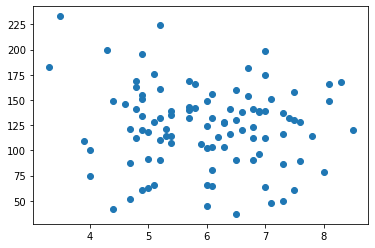

In [10]:
# EDA
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'], df['iq'])  # Data is linear so Logistic Regression can be used

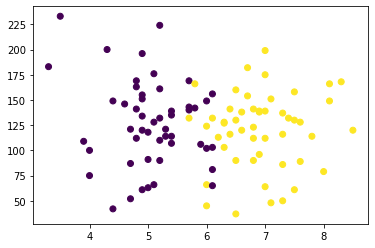

In [11]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [12]:
# Feature selection - will ignore as of now
# Extract input and output cols
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [13]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [15]:
y.shape

(100,)

In [19]:
# Scale the values
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x, y, test_size = 0.1) # 10 rows test mei and 90 rows training mei

In [20]:
x_train # randamoly koi bhi row training data mei chala gaya

,cgpa,iq
51,4.8,141.0
65,8.1,166.0
77,7.3,50.0
43,6.8,141.0
50,3.5,233.0
...,...,...
4,5.8,142.0
84,5.7,169.0
98,6.3,103.0
59,4.8,112.0


In [21]:
y_train

51    0
65    1
77    1
43    1
50    0
     ..
4     0
84    0
98    1
59    0
16    0
Name: placement, Length: 90, dtype: int64

In [22]:
x_test

,cgpa,iq
34,4.8,163.0
82,6.5,37.0
91,7.5,158.0
86,5.1,128.0
89,4.9,151.0
56,6.1,65.0
85,5.8,166.0
21,7.1,151.0
60,6.9,139.0
53,8.3,168.0


In [26]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [28]:
x_train = scaler.fit_transform(x_train)
x_train

array([[-1.01882269,  0.46932665],
       [ 1.88790487,  1.10622952],
       [ 1.18324364, -1.8489998 ],
       [ 0.74283038,  0.46932665],
       [-2.16389718,  2.81312922],
       [ 0.56666507,  0.3928983 ],
       [-0.66649208,  0.97884895],
       [-1.01882269,  1.18265787],
       [-0.49032677, -0.39686126],
       [ 0.03816915, -1.97638038],
       [ 1.35940895,  0.18908939],
       [-0.66649208, -0.82995521],
       [-0.57840942, -0.21852845],
       [ 1.4474916 ,  0.13813716],
       [ 0.83091303,  0.3928983 ],
       [-1.3711533 ,  0.67313557],
       [ 1.18324364,  0.36742219],
       [-0.49032677,  0.41837442],
       [-1.10690534, -0.90638355],
       [-0.93074004, -0.06567176],
       [-0.84265738, -0.80447909],
       [ 1.18324364, -0.93185967],
       [ 0.1262518 , -0.49876572],
       [-0.57840942, -0.04019565],
       [ 0.47858242, -0.82995521],
       [ 1.2713263 ,  0.24004162],
       [ 1.18324364, -0.16757622],
       [-0.22607881,  0.52027888],
       [ 0.47858242,

In [30]:
x_test = scaler.transform(x_test)
x_test

array([[-1.01882269,  1.02980118],
       [ 0.47858242, -2.1801893 ],
       [ 1.35940895,  0.9024206 ],
       [-0.75457473,  0.13813716],
       [-0.93074004,  0.7240878 ],
       [ 0.1262518 , -1.46685808],
       [-0.13799616,  1.10622952],
       [ 1.00707834,  0.7240878 ],
       [ 0.83091303,  0.41837442],
       [ 2.06407017,  1.15718175]])

In [32]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [33]:
# model training
clf.fit(x_train, y_train)

LogisticRegression()

In [34]:
# Model Evaluation
clf.predict(x_test)

array([0, 1, 1, 0, 0, 1, 0, 1, 1, 1], dtype=int64)

In [35]:
y_test

34    0
82    1
91    1
86    0
89    0
56    0
85    1
21    1
60    1
53    1
Name: placement, dtype: int64

In [36]:
y_pred = clf.predict(x_test)

In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred) # model accuracy is 80%

0.8

<AxesSubplot:>

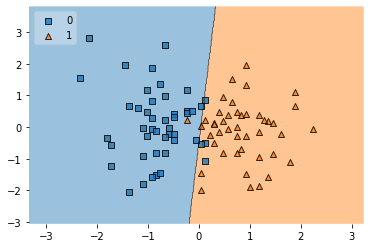

In [42]:
# To check how ML visulizes pattern in the data - Dicision Boundry need to be used
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train,y_train.values, clf=clf, legend=2)

In [43]:
import pickle # pickle file ko object mei convert kar deta hai
pickle.dump(clf,open('model.pkl','wb'))

In [ ]:
# For Deployment cloud platforms - Heroku, AWS, GCP - Google Cloud Platform
# Heroku - 5 application free mei host kar sakte ho